# Collocation: one polynomial, two formulations

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pierrelux/rlbook/blob/main/lab/notebooks/08_collocation_two_formulations.ipynb)

This 60-minute session turns an ODE into constraints an optimizer can evaluate.
We will describe the same state curve by integrating its slopes and by
differentiating its values, then solve a control problem using both descriptions.

By the end, you should be able to:

1. Construct integration, evaluation, and differentiation matrices from nodes.
2. Distinguish collocation nodes, state-support nodes, and control-support nodes.
3. Assemble stage, endpoint, and boundary constraints in either formulation.
4. Check equivalence and distinguish discrete feasibility from ODE accuracy.

Allow 15 minutes for one interval, 20 for the general construction, and 25 for
optimization. Familiarity with derivatives, polynomial interpolation, and equality
constraints is sufficient. [Notebook 07](07_lagrange_operators.ipynb) is a useful
companion, but this notebook includes every function it uses.

Run all cells in order in Colab, local Jupyter, or the book's browser lab
(select **Python (XPython)** there). Only NumPy, SciPy, and Matplotlib are needed;
there are no downloads, repository imports, or package-install cells. The
computations are small CPU problems; allow extra time for a browser kernel to start.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

np.set_printoptions(precision=5, suppress=True)
plt.rcParams.update({
    'figure.figsize': (8, 3.3), 'figure.dpi': 110,
    'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False,
    'legend.frameon': False, 'lines.linewidth': 2,
    'axes.prop_cycle': plt.cycler(color=['#0072B2', '#D55E00', '#009E73', '#CC79A7']),
})

from numpy.polynomial import Polynomial

## 1. Recover a state curve from a control (15 minutes)

On one interval of width h, let ẋ = u and let the control vary linearly
between u<sub>L</sub> and u<sub>R</sub>. In local time τ = (t − t<sub>k</sub>)/h,

$$
u_h(\tau)=(1-\tau)u_L+\tau u_R,\qquad
p(\tau)=x_L+h\left[u_L\tau+\frac{u_R-u_L}{2}\tau^2\right].
$$

The factor h converts a physical-time slope to a local-time derivative:
p′(τ) = h u<sub>h</sub>(τ). Two control values determine a linear slope polynomial;
its integral is quadratic and needs three state values to represent it by interpolation.

**Predict before running:** if h doubles while x<sub>L</sub>, u<sub>L</sub>, u<sub>R</sub> stay fixed,
what happens to the endpoint displacement and the physical-time slope?

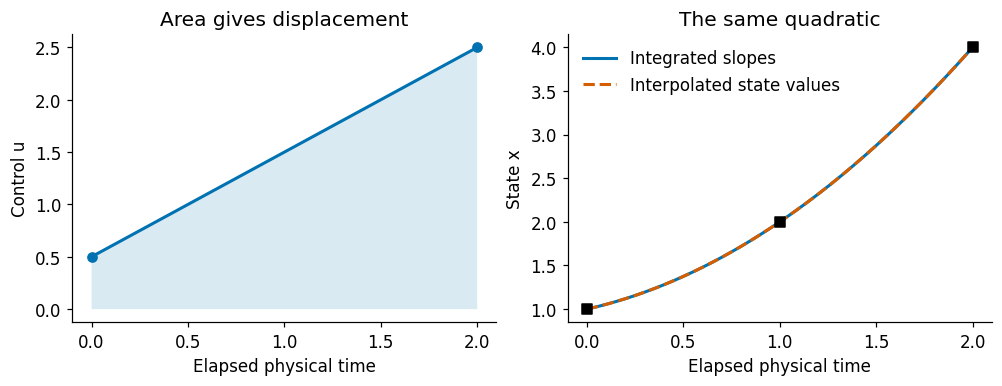

State-support values: [1. 2. 4.]
Displacement: 3.0 = trapezoid area: 3.0


In [2]:
def cardinal_basis(nodes):
    """Build l_j(tau) = product_{m != j} (tau-node_m)/(node_j-node_m)."""
    nodes = np.asarray(nodes, dtype=float)
    if nodes.ndim != 1 or len(nodes) == 0:
        raise ValueError('Use a nonempty one-dimensional node array.')
    if not np.all(np.isfinite(nodes)) or np.any((nodes < 0) | (nodes > 1)):
        raise ValueError('Nodes must be finite and in [0, 1].')
    if len(np.unique(nodes)) != len(nodes):
        raise ValueError('Interpolation nodes must be distinct.')
    basis = []
    for j, node in enumerate(nodes):
        p = Polynomial([1.0])
        for m, other in enumerate(nodes):
            if m != j:
                p = p * Polynomial([-other, 1.0]) / (node - other)
        basis.append(p)
    return basis


def evaluate_basis(basis, points):
    return np.column_stack([p(np.atleast_1d(points)) for p in basis])


h, x_left = 2.0, 1.0
u_left, u_right = 0.5, 2.5
tau = np.linspace(0, 1, 201)
control = Polynomial([u_left, u_right - u_left])
p_integral = Polynomial([x_left]) + h * control.integ()
state_nodes = np.array([0.0, 0.5, 1.0])
state_values = p_integral(state_nodes)
state_basis = cardinal_basis(state_nodes)
p_values = sum((v * p for v, p in zip(state_values, state_basis)), Polynomial([0]))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), constrained_layout=True)
axes[0].plot(h*tau, control(tau), label='Linear control')
axes[0].fill_between(h*tau, control(tau), alpha=0.15)
axes[0].scatter([0, h], [u_left, u_right], color='#0072B2', zorder=3)
axes[0].set(xlabel='Elapsed physical time', ylabel='Control u', title='Area gives displacement')
axes[1].plot(h*tau, p_integral(tau), label='Integrated slopes')
axes[1].plot(h*tau, p_values(tau), '--', label='Interpolated state values')
axes[1].scatter(h*state_nodes, state_values, marker='s', color='black', zorder=3)
axes[1].set(xlabel='Elapsed physical time', ylabel='State x', title='The same quadratic')
axes[1].legend()
plt.show()
print('State-support values:', state_values)
print('Displacement:', p_integral(1)-x_left, '= trapezoid area:', h*(u_left+u_right)/2)
np.testing.assert_allclose(p_integral(tau), p_values(tau), atol=1e-13)
np.testing.assert_allclose(p_values.deriv()(tau)/h, control(tau), atol=1e-13)

The squares store values of the state curve; the two circles store endpoint
controls, which are also the physical slopes in this example. These are different
roles even when some of their times coincide.

**Modify:** change `h` to 1 and then 4. Explain why the displacement changes
even though dividing the local derivative by `h` returns the same control.

## 2. Turn the construction into fixed matrices (20 minutes)

For s collocation nodes τ<sub>i</sub>, interpolate the physical slopes with
s cardinal functions ℓ<sub>j</sub>. Their integrals give

$$
A_{ij}=\int_0^{\tau_i}\ell_j(\eta)\,d\eta,
\qquad b_j=\int_0^1\ell_j(\eta)\,d\eta.
$$

The state has degree at most s, so choose **s+1 state-support nodes**
σ<sub>r</sub> and their basis L<sub>r</sub>. Evaluation and differentiation at the
collocation nodes give E<sub>ir</sub> = L<sub>r</sub>(τ<sub>i</sub>) and D<sub>ir</sub> = L′<sub>r</sub>(τ<sub>i</sub>).
The endpoint rows are e<sub>L</sub> = (L<sub>r</sub>(0))<sub>r</sub> and e<sub>R</sub> = (L<sub>r</sub>(1))<sub>r</sub>.
Controls have their own nodes ν<sub>q</sub> and basis M<sub>q</sub>, giving
B<sub>iq</sub> = M<sub>q</sub>(τ<sub>i</sub>).

For trapezoidal collocation, use slope nodes (0,1) and state supports
(0, ½, 1). The resulting D is **2 × 3**. The square
differentiation matrix at three nodes in notebook 07 has a different job.

In [3]:
def make_operators(slope_nodes, state_nodes, control_nodes):
    s = len(slope_nodes)
    if len(state_nodes) != s + 1:
        raise ValueError('s slope nodes require s+1 state supports.')
    slope_basis = cardinal_basis(slope_nodes)
    state_basis = cardinal_basis(state_nodes)
    control_basis = cardinal_basis(control_nodes)
    integrals = [p.integ() for p in slope_basis]
    return dict(
        nodes=np.array(slope_nodes), supports=np.array(state_nodes),
        A=np.column_stack([p(slope_nodes)-p(0) for p in integrals]),
        b=np.array([p(1)-p(0) for p in integrals]),
        E=evaluate_basis(state_basis, slope_nodes),
        D=evaluate_basis([p.deriv() for p in state_basis], slope_nodes),
        eL=evaluate_basis(state_basis, [0])[0],
        eR=evaluate_basis(state_basis, [1])[0],
        B=evaluate_basis(control_basis, slope_nodes),
        slope_basis=slope_basis, state_basis=state_basis, control_basis=control_basis,
    )


trap = make_operators([0, 1], [0, 0.5, 1], [0, 1])
for name in ['A', 'b', 'E', 'D', 'B']:
    print(f'{name} =\n{trap[name]}')
np.testing.assert_allclose(trap['D'], [[-3, 4, -1], [1, -4, 3]])

A =
[[0.  0. ]
 [0.5 0.5]]
b =
[0.5 0.5]
E =
[[1. 0. 0.]
 [0. 0. 1.]]
D =
[[-3.  4. -1.]
 [ 1. -4.  3.]]
B =
[[1. 0.]
 [0. 1.]]


For vector dynamics <b>ẋ</b> = f(<b>x</b>, <b>u</b>, t), rows of
X<sub>k</sub> ∈ ℝ<sup>s×n</sup> store stage states and rows of
X̂<sub>k</sub> ∈ ℝ<sup>(s+1)×n</sup> store state-support values.
Control-support values form U<sub>k</sub>, so the stage controls are BU<sub>k</sub>.
Each row of F<sub>k</sub> is f(X<sub>k,i</sub>, (BU<sub>k</sub>)<sub>i</sub>, t<sub>k</sub> + h<sub>k</sub>τ<sub>i</sub>).

| Integration form | Differentiation form |
|:--|:--|
| Unknowns: mesh states x<sub>k</sub>, stage states X<sub>k</sub>, controls U<sub>k</sub>. | Unknowns: mesh states x<sub>k</sub>, support states X̂<sub>k</sub>, controls U<sub>k</sub>. |
| Stage constraint: X<sub>k</sub> = <b>1</b>x<sub>k</sub><sup>⊤</sup> + h<sub>k</sub>AF<sub>k</sub>. | Stage evaluation: X<sub>k</sub> = EX̂<sub>k</sub>. |
| Endpoint constraint: x<sub>k+1</sub> = x<sub>k</sub> + h<sub>k</sub>b<sup>⊤</sup>F<sub>k</sub>. | ODE constraint: DX̂<sub>k</sub> = h<sub>k</sub>F<sub>k</sub>. |
| The integrated curve starts at x<sub>k</sub> by construction. | Endpoint constraints: e<sub>L</sub>X̂<sub>k</sub> = x<sub>k</sub>, e<sub>R</sub>X̂<sub>k</sub> = x<sub>k+1</sub>. |

Both use the discrete objective

$$
J_h=c_f(x_N,t_N)+\sum_k h_k\sum_i b_i
c(X_{k,i},(BU_k)_i,t_k+h_k\tau_i).
$$

Add the same endpoint boundary equations q(x<sub>0</sub>, x<sub>N</sub>) = 0 and sampled path
inequalities in either form:

$$
g(X_{k,i},(BU_k)_i,t_k+h_k\tau_i)\le0.
$$

Sharing control endpoint values between intervals makes a piecewise-linear
control continuous. Continuity is a choice about the control representation,
not a requirement of collocation itself.

### Why the integral form needs stage constraints

Take ẋ = x, x<sub>L</sub> = 1, h = 1, and a single midpoint stage. Guess its state
is X = 3. Interpolating the sampled slope gives p(τ) = 1 + 3τ.
Its slope agrees with f(X) = 3, but the curve's own midpoint is 2.5.

**Predict:** does choosing x<sub>R</sub> = p(1) = 4 make this a feasible collocation piece?

In [4]:
stored_stage = 3.0
p_bad = Polynomial([1.0, stored_stage])
curve_stage = p_bad(0.5)
stage_defect = stored_stage - curve_stage
endpoint_defect = 4.0 - p_bad(1.0)
ode_defect = p_bad.deriv()(0.5) - curve_stage  # f(x)=x at the curve's state
print('Endpoint defect:', endpoint_defect)
print('Stage consistency defect:', stage_defect)
print('ODE defect at the actual curve midpoint:', ode_defect)
assert endpoint_defect == 0 and stage_defect != 0

# Solve X = 1 + X/2: the consistent stage is X=2, with endpoint x_R=3.
consistent_stage = 2.0
assert consistent_stage == 1 + consistent_stage/2

Endpoint defect: 0.0
Stage consistency defect: 0.5
ODE defect at the actual curve midpoint: 0.5


The endpoint equation alone cannot repair the inconsistent stage. In the
differentiation form, evaluating EX̂ places the stage on the curve
automatically; the remaining constraint matches the ODE's slope there.

At a feasible point, the derivative is a degree-(s−1) polynomial fixed by
its s nodal slopes. Integrating it from the left endpoint recovers exactly
the state polynomial. For matching nodes, degree, controls, quadrature, and
constraint sampling, both formulations therefore describe the same feasible
trajectories and objective. Their residual vectors at infeasible candidates
need not be equal.

The identities E − <b>1</b>e<sub>L</sub> = AD and e<sub>R</sub> − e<sub>L</sub> = b<sup>⊤</sup>D express this
polynomial equivalence without involving any particular dynamics.

In [5]:
def check_operators(rule):
    s = len(rule['nodes'])
    for degree in range(s + 1):
        values = rule['supports']**degree
        exact_derivative = (np.zeros(s) if degree == 0
                            else degree*rule['nodes']**(degree-1))
        np.testing.assert_allclose(rule['E'] @ values, rule['nodes']**degree, atol=1e-12)
        np.testing.assert_allclose(rule['D'] @ values, exact_derivative, atol=1e-12)
    np.testing.assert_allclose(rule['E']-rule['eL'], rule['A'] @ rule['D'], atol=1e-12)
    np.testing.assert_allclose(rule['eR']-rule['eL'], rule['b'] @ rule['D'], atol=1e-12)


rules = {
    'midpoint': make_operators([0.5], [0, 1], [0, 1]),
    'trapezoidal': trap,
    'Simpson': make_operators([0, 0.5, 1], [0, 1/3, 2/3, 1], [0, 1]),
}
for name, rule in rules.items():
    check_operators(rule)
    print(name, 'quadrature weights:', rule['b'])

# Nonunit widths catch a missing h in either formulation.
for width in [0.2, 1.0, 2.7]:
    slopes = np.array([0.5, 2.5])
    integrated = Polynomial([1.0]) + width * sum(
        (v*(p.integ()-p.integ()(0)) for v, p in zip(slopes, trap['slope_basis'])),
        Polynomial([0]),
    )
    supports = integrated(trap['supports'])
    np.testing.assert_allclose(trap['D'] @ supports, width*slopes, atol=1e-12)
    np.testing.assert_allclose(trap['E'] @ supports, 1+width*trap['A'] @ slopes, atol=1e-12)
print('Polynomial exactness, integration identities, and time scaling passed.')

midpoint quadrature weights: [1.]
trapezoidal quadrature weights: [0.5 0.5]
Simpson quadrature weights: [0.16667 0.66667 0.16667]
Polynomial exactness, integration identities, and time scaling passed.


**Modify:** generate operators for two interior Gauss nodes
½ ± √3/6 using three state supports. Check the identities
again. Why must changing to three slope nodes also add a fourth state support?

## 3. Assemble the optimization problem (25 minutes)

Move from x(0) = 0 to x(1) = 1 while minimizing the control energy:

$$
J=\int_0^1u(t)^2\,dt.
$$

Start with ẋ = u and then add decay, ẋ = −x + u.
The code below accepts a in ẋ = ax + u. Eight equal intervals share
their mesh states and control endpoints. Stage or support states are local to
each interval. Keeping separate copies makes every consistency equation visible.

The decision vector packs **mesh states, local states, shared controls**, in that
order. The two formulations use the same trapezoidal weights in the objective.
There are no path inequalities in this first optimization example.

**Predict:** for a = 0, could a nonconstant control use less energy than u = 1?
For a = −1, should it be cheaper to apply control earlier or later?

In [6]:
def transfer_problem(a=0.0, N=8, form='integral', rule=trap):
    """Scalar teaching problem; all residuals and derivatives are explicit."""
    if form not in ('integral', 'differential'):
        raise ValueError('Choose integral or differential.')
    h = 1.0/N
    s = len(rule['nodes'])
    local_size = s if form == 'integral' else s+1
    control_start = N+1+N*local_size
    nvar = control_start+N+1
    C = np.eye(s) if form == 'integral' else rule['E']

    def unpack(z):
        return z[:N+1], z[N+1:control_start].reshape(N, local_size), z[control_start:]

    def objective(z):
        _, _, u = unpack(z)
        return sum(h*np.dot(rule['b'], (rule['B'] @ u[k:k+2])**2) for k in range(N))

    def gradient(z):
        _, _, u = unpack(z)
        g = np.zeros(nvar)
        for k in range(N):
            stage_u = rule['B'] @ u[k:k+2]
            g[control_start+k:control_start+k+2] += 2*h*rule['B'].T @ (rule['b']*stage_u)
        return g

    def equalities(z):
        x, local, u = unpack(z)
        residuals = [x[0], x[-1]-1]
        for k in range(N):
            stage_x = C @ local[k]
            F = a*stage_x + rule['B'] @ u[k:k+2]
            if form == 'integral':
                residuals.extend(local[k]-x[k]-h*rule['A'] @ F)
                residuals.append(x[k+1]-x[k]-h*rule['b'] @ F)
            else:
                residuals.extend(rule['D'] @ local[k]-h*F)
                residuals.extend([rule['eL'] @ local[k]-x[k], rule['eR'] @ local[k]-x[k+1]])
        return np.asarray(residuals)

    # For this linear ODE the Jacobian is constant. Each block differentiates
    # the corresponding residual above; no numerical differentiation is used.
    rows_per_interval = s+1 if form == 'integral' else s+2
    J = np.zeros((2+N*rows_per_interval, nvar))
    J[0, 0], J[1, N] = 1, 1
    for k in range(N):
        r = 2+k*rows_per_interval
        local_cols = slice(N+1+k*local_size, N+1+(k+1)*local_size)
        u_cols = slice(control_start+k, control_start+k+2)
        if form == 'integral':
            J[r:r+s, k] = -1
            J[r:r+s, local_cols] = np.eye(s)-h*a*rule['A']
            J[r:r+s, u_cols] = -h*rule['A'] @ rule['B']
            J[r+s, k:k+2] = [-1, 1]
            J[r+s, local_cols] = -h*a*rule['b']
            J[r+s, u_cols] = -h*rule['b'] @ rule['B']
        else:
            J[r:r+s, local_cols] = rule['D']-h*a*rule['E']
            J[r:r+s, u_cols] = -h*rule['B']
            J[r+s, local_cols], J[r+s, k] = rule['eL'], -1
            J[r+s+1, local_cols], J[r+s+1, k+1] = rule['eR'], -1

    # x(t)=t and u(t)=1-a*t are feasible in both representations.
    mesh = np.linspace(0, 1, N+1)
    local_nodes = rule['nodes'] if form == 'integral' else rule['supports']
    local0 = mesh[:-1, None]+h*local_nodes
    z0 = np.concatenate([mesh, local0.ravel(), 1-a*mesh])
    return dict(fun=objective, jac=gradient, eq=equalities, eq_jac=J,
                z0=z0, unpack=unpack, h=h, N=N, form=form, rule=rule, a=a)


def solve_transfer(**kwargs):
    problem = transfer_problem(**kwargs)
    result = minimize(problem['fun'], problem['z0'], jac=problem['jac'], method='SLSQP',
                      constraints={'type': 'eq', 'fun': problem['eq'],
                                   'jac': lambda z: problem['eq_jac']},
                      options={'ftol': 1e-11, 'maxiter': 300})
    defect = np.max(np.abs(problem['eq'](result.x)))
    if not result.success or defect > 1e-8:
        raise RuntimeError(f'{result.message}; maximum defect={defect:.3g}')
    return problem, result


solutions = {}
for a in [0.0, -1.0]:
    for form in ['integral', 'differential']:
        problem, result = solve_transfer(a=a, form=form)
        solutions[a, form] = problem, result
        print(f'a={a:4.1f}, {form:12s}: J={result.fun:.9f}, '
              f'variables={len(result.x)}, defect={np.max(np.abs(problem["eq"](result.x))):.1e}')

a= 0.0, integral    : J=1.000000000, variables=34, defect=0.0e+00
a= 0.0, differential: J=1.000000000, variables=42, defect=0.0e+00
a=-1.0, integral    : J=2.319762475, variables=34, defect=5.6e-17
a=-1.0, differential: J=2.319762475, variables=42, defect=3.3e-16


The array equations above extend to vector and nonlinear dynamics by evaluating
f at each stage. The constant Jacobian used here relies specifically on
f(x,u) = ax+u; nonlinear dynamics require its state and control derivatives
at the current candidate. The pendulum in the next notebook makes that change.

### Reconstruct and compare the curves

For the integral form, reconstruct a piece from its optimized stage slopes.
For the differential form, interpolate the optimized support states.
The derivative of either reconstruction lets us evaluate the ODE residual
between collocation nodes as well as at them.

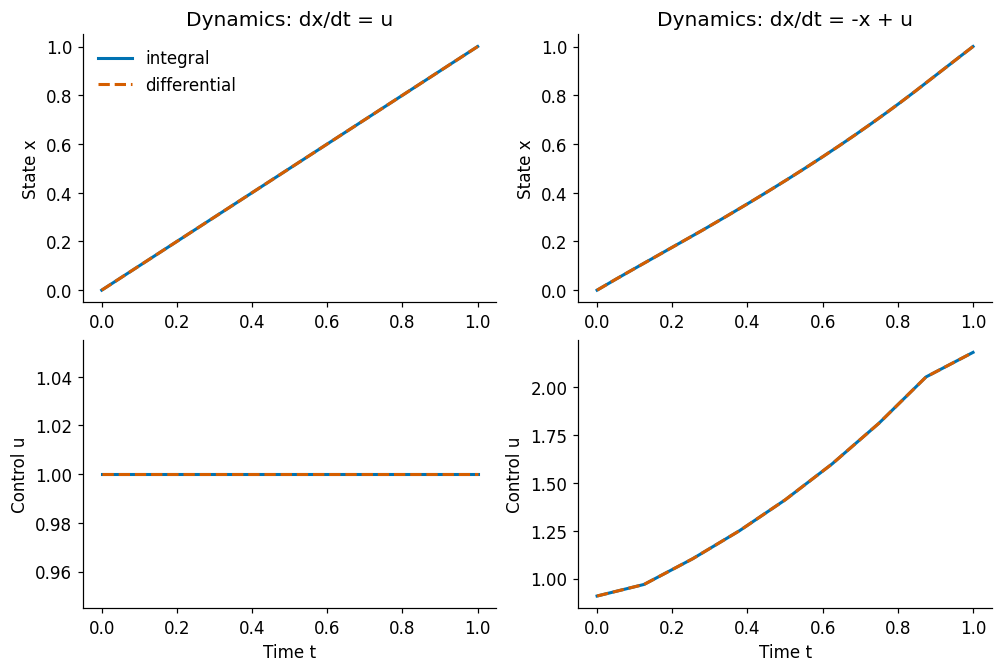

Both formulations agree; the no-decay optimum is u=1, J=1.


In [7]:
def reconstruct_transfer(problem, z, samples=31):
    x, local, u = problem['unpack'](z)
    rule, h, a = problem['rule'], problem['h'], problem['a']
    tau = np.linspace(0, 1, samples)
    times, states, controls, residuals = [], [], [], []
    for k in range(problem['N']):
        up = sum((v*p for v, p in zip(u[k:k+2], rule['control_basis'])), Polynomial([0]))
        if problem['form'] == 'integral':
            F = a*local[k]+rule['B'] @ u[k:k+2]
            xp = Polynomial([x[k]])
            for value, basis in zip(F, rule['slope_basis']):
                antiderivative = basis.integ()
                xp += h*value*(antiderivative-antiderivative(0))
        else:
            xp = sum((v*p for v, p in zip(local[k], rule['state_basis'])), Polynomial([0]))
        times.extend(h*(k+tau))
        states.extend(xp(tau))
        controls.extend(up(tau))
        residuals.extend(xp.deriv()(tau)/h-a*xp(tau)-up(tau))
    return tuple(np.asarray(v) for v in (times, states, controls, residuals))


fig, axes = plt.subplots(2, 2, figsize=(9, 6), constrained_layout=True)
for column, a in enumerate([0.0, -1.0]):
    curves = []
    for form, style in [('integral', '-'), ('differential', '--')]:
        problem, result = solutions[a, form]
        t, x, u, residual = reconstruct_transfer(problem, result.x)
        curves.append((x, u))
        axes[0, column].plot(t, x, style, label=form)
        axes[1, column].plot(t, u, style, label=form)
    np.testing.assert_allclose(curves[0], curves[1], atol=2e-5)
    axes[0, column].set(title='Dynamics: dx/dt = ' + ('u' if a == 0 else '-x + u'), ylabel='State x')
    axes[1, column].set(xlabel='Time t', ylabel='Control u')
axes[0, 0].legend()
plt.show()

p0, r0 = solutions[0.0, 'integral']
np.testing.assert_allclose(p0['unpack'](r0.x)[2], 1, atol=1e-8)
np.testing.assert_allclose(r0.fun, 1, atol=1e-9)
print('Both formulations agree; the no-decay optimum is u=1, J=1.')

For ẋ = −x + u, the continuous solution is
x<sub>★</sub>(t) = sinh(t)/sinh(1) and u<sub>★</sub>(t) = e<sup>t</sup>/sinh(1),
with cost J<sub>★</sub> = 2/(1 − e<sup>−2</sup>). The endpoint condition gives

$$
1=\int_0^1 e^{-(1-t)}u(t)\,dt.
$$

Applying Cauchy–Schwarz gives the minimum cost; equality requires u(t)
to be proportional to e<sup>t</sup>.

**Predict:** if the optimizer makes every discrete defect almost zero, will
the ODE residual between nodes also be almost zero? Run a mesh refinement
while keeping the degree fixed.

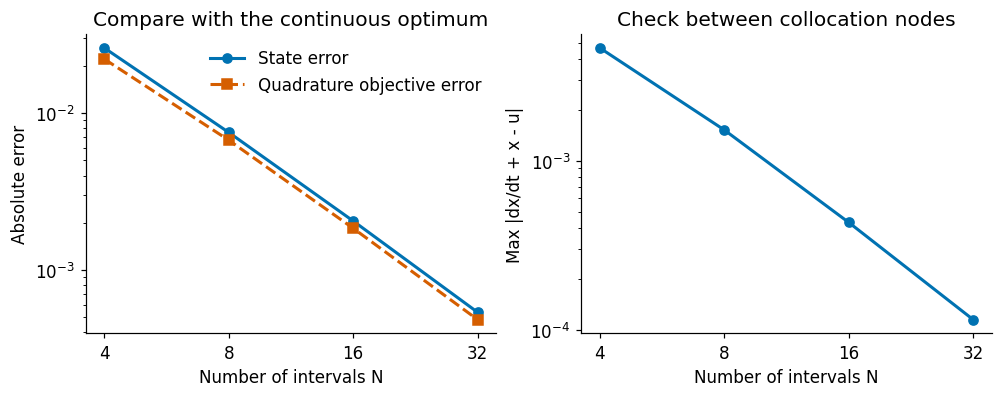

Refinement reduces state error, between-node residual, and objective error.


In [8]:
mesh_sizes = [4, 8, 16, 32]
refinement = []
exact_cost = 2/(1-np.exp(-2))
for N in mesh_sizes:
    problem, result = solve_transfer(a=-1, N=N, form='differential')
    t, x, u, ode_residual = reconstruct_transfer(problem, result.x)
    refinement.append([np.max(np.abs(x-np.sinh(t)/np.sinh(1))),
                       np.max(np.abs(ode_residual)), abs(result.fun-exact_cost)])
refinement = np.asarray(refinement)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), constrained_layout=True)
axes[0].loglog(mesh_sizes, refinement[:, 0], 'o-', label='State error')
axes[0].loglog(mesh_sizes, refinement[:, 2], 's--', label='Quadrature objective error')
axes[0].set(xlabel='Number of intervals N', ylabel='Absolute error', title='Compare with the continuous optimum')
axes[0].legend()
axes[1].loglog(mesh_sizes, refinement[:, 1], 'o-')
axes[1].set(xlabel='Number of intervals N', ylabel='Max |dx/dt + x - u|', title='Check between collocation nodes')
for ax in axes:
    ax.set_xticks(mesh_sizes, labels=[str(N) for N in mesh_sizes], minor=False)
    ax.set_xticks([], minor=True)
plt.show()
assert np.all(refinement[-1] < refinement[0])
print('Refinement reduces state error, between-node residual, and objective error.')

The optimizer solves a finite approximation. Its equality residual checks that
approximation; the between-node ODE residual checks how well the reconstructed
curve follows the continuous model. Matching sampled path inequalities would
likewise not guarantee that a path bound holds between samples.

**Modify:** rerun the transfer with `rule=rules['midpoint']`, then
`rule=rules['Simpson']`. Keep the control representation fixed. Explain why
increasing the state degree alone does not make the piecewise-linear control exact.

## Checks and discussion

The next cell checks the supplied objective and constraint derivatives at a
perturbed, generally infeasible candidate. Finite differences are an independent
check here; they are not used to optimize the trajectory.

In [9]:
def central_jacobian(function, point, epsilon=1e-6):
    point = np.asarray(point, dtype=float)
    columns = []
    for j in range(len(point)):
        step = np.zeros_like(point)
        step[j] = epsilon
        columns.append((np.atleast_1d(function(point+step))
                        - np.atleast_1d(function(point-step)))/(2*epsilon))
    return np.column_stack(columns)


for form in ['integral', 'differential']:
    problem = transfer_problem(a=-1, N=3, form=form)
    point = problem['z0']+0.03*np.sin(np.arange(len(problem['z0'])))
    np.testing.assert_allclose(central_jacobian(problem['fun'], point)[0],
                               problem['jac'](point), atol=1e-8)
    np.testing.assert_allclose(central_jacobian(problem['eq'], point),
                               problem['eq_jac'], atol=1e-8)
print('All checks passed. Both formulations describe the same feasible polynomial construction.')

All checks passed. Both formulations describe the same feasible polynomial construction.


Before moving to [notebook 09](09_collocation_and_unstable_shooting.ipynb), explain:

1. Which consistency condition is built into each polynomial representation?
2. Why do s slope nodes require s+1 state-support values?
3. Where does the interval width appear, and what would omitting it change?
4. Which quantities must stay fixed for a fair comparison of the formulations?

The next session keeps the discretization fixed and changes whether the optimizer
retains the state variables or eliminates them through a rollout.